# AI Job Market — Geographic & Industry Demand Analysis
**Author**: Rendy Herdianto 
**Date**: 2026-03-31  
**Dataset**: [AI Job Market Insights](/kaggle/input/ai-job-market-trends)

---

## Description
This notebook analyses geographic and industry-level demand for AI talent across job postings
spanning September 2023 – September 2025. It surfaces which locations concentrate the most
opportunity, how salary varies by city, which industries dominate each geographic cluster,
and how posting volume is distributed across industries.

## Objectives
1. Rank top hiring cities by posting volume and share
2. Compare salary distributions across the highest-volume locations
3. Visualise industry composition within top cities
4. Quantify industry-level posting volume and associated salary benchmarks
5. Identify role concentration patterns by location

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Preparation](#3-data-preparation)
4. [Top Hiring Cities](#4-top-hiring-cities)
5. [Salary by Location](#5-salary-by-location)
6. [Industry Composition by City](#6-industry-composition-by-city)
7. [Industry Posting Volume & Salary](#7-industry-posting-volume--salary)
8. [Role Concentration by Location](#8-role-concentration-by-location)
9. [Key Insights](#9-key-insights)

## 1. Environment Setup

In [1]:
import subprocess, sys
for pkg in ["loguru"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

CalledProcessError: Command '['c:\\Users\\Admin\\project\\Data Analysis\\ai_job_market\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'loguru', '-q']' returned non-zero exit status 1.

In [2]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
FIGURE_SIZE = (12, 5)
PALETTE     = "viridis"

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": FIGURE_SIZE})
print("Environment ready.")

Environment ready.


In [3]:
# ── Dataset Sources ───────────────────────────────────────────────────────────
import os

# Resolve project root — works whether CWD is project root or notebooks/03_analysis/
_cwd = Path(os.path.abspath(""))
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parents[1]

KAGGLE_PATH   = Path("/kaggle/input/ai-job-market-insights/ai_job_market.csv")
ENRICHED_PATH = PROJECT_ROOT / "data/enriched/ai_job_market_enriched.csv"
RAW_PATH      = PROJECT_ROOT / "data/raw/ai_job_market.csv"


def resolve_dataset_path() -> tuple[Path, bool]:
    if KAGGLE_PATH.exists():   return KAGGLE_PATH, True
    if ENRICHED_PATH.exists(): return ENRICHED_PATH, False
    if RAW_PATH.exists():      return RAW_PATH, True
    raise FileNotFoundError("Dataset not found.")


DATASET_PATH, IS_RAW = resolve_dataset_path()
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset     : {DATASET_PATH}  |  raw_mode={IS_RAW}")


Project root: c:\Users\Admin\project\Data Analysis\ai_job_market
Dataset     : c:\Users\Admin\project\Data Analysis\ai_job_market\data\enriched\ai_job_market_enriched.csv  |  raw_mode=False


In [4]:
def save_fig(name, dpi=150):
    if not Path("/kaggle").exists():
        out = Path("outputs/figures")
        out.mkdir(parents=True, exist_ok=True)
        plt.savefig(out / name, dpi=dpi, bbox_inches="tight")

def fmt_usd(ax, axis="y"):
    fmt = mticker.FuncFormatter(lambda v, _: f"${v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

def palette(n):
    return sns.color_palette(PALETTE, n_colors=n).as_hex()

## 2. Dataset Overview

In [5]:
parse_dates = None if IS_RAW else ["posted_date"]
df_raw = pd.read_csv(DATASET_PATH, low_memory=False, parse_dates=parse_dates)
print(f"Shape   : {df_raw.shape}")
df_raw.head(3)

Shape   : (2000, 21)


,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred,salary_min,salary_max,salary_avg,skills_count,posted_year,posted_month,posted_quarter,days_since_posted,experience_order
0,1,Foster and Sons,Healthcare,Data Analyst,numpy;reinforcement learning;pytorch;scikit-le...,Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,kdb+;langchain,"92,860.00","109,598.00","101,229.00",6,2025,8,3,41,1
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,scikit-learn;cuda;sql;pandas,Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,fastapi;kdb+;tensorflow,"78,523.00","144,875.00","111,699.00",4,2024,3,1,557,2
2,3,King Inc,Tech,Quant Researcher,mlflow;fastapi;azure;pytorch;sql;gcp,Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,bigquery;pytorch;scikit-learn,"124,496.00","217,204.00","170,850.00",6,2025,9,3,12,0


## 3. Data Preparation

In [6]:
df = df_raw.copy()

if IS_RAW:
    if "salary_range_usd" in df.columns:
        def _parse_min(s):
            m = re.search(r"(\d+)", str(s).replace(",", ""))
            return float(m.group(1)) if m else None
        def _parse_max(s):
            m = re.search(r"-\s*(\d+)", str(s).replace(",", ""))
            return float(m.group(1)) if m else None
        df["salary_min"] = df["salary_range_usd"].apply(_parse_min)
        df["salary_max"] = df["salary_range_usd"].apply(_parse_max)
        mask = df["salary_min"].notna() & df["salary_max"].notna()
        df.loc[mask, "salary_avg"] = (df.loc[mask, "salary_min"] + df.loc[mask, "salary_max"]) / 2

for col in ["location", "industry", "job_title"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print(f"Working dataset : {df.shape}")
print(f"Unique locations: {df['location'].nunique()}")
print(f"Unique industries: {df['industry'].nunique()}")

Working dataset : (2000, 21)
Unique locations: 2000
Unique industries: 7


## 4. Top Hiring Cities

The horizontal bar chart ranks locations by total AI job posting volume. Cities at
the top are the primary hubs where AI talent demand is most concentrated. Job seekers
targeting these markets face the most opportunity but also the most competition.

In [7]:
TOP_N_CITIES = 15
city_counts = (
    df["location"].value_counts()
    .head(TOP_N_CITIES)
    .reset_index()
)
city_counts.columns = ["location", "count"]
city_counts["share_pct"] = (city_counts["count"] / len(df) * 100).round(2)
city_counts

,location,count,share_pct
0,"Tracybury, AR",1,0.05
1,"Lake Scott, CU",1,0.05
2,"East Paige, CM",1,0.05
3,"Perezview, FI",1,0.05
4,"North Desireeland, NE",1,0.05
5,"South Kevin, TZ",1,0.05
6,"West Shawn, LR",1,0.05
7,"Port Hailey, RU",1,0.05
8,"Butlermouth, GB",1,0.05
9,"Nicoleshire, BA",1,0.05


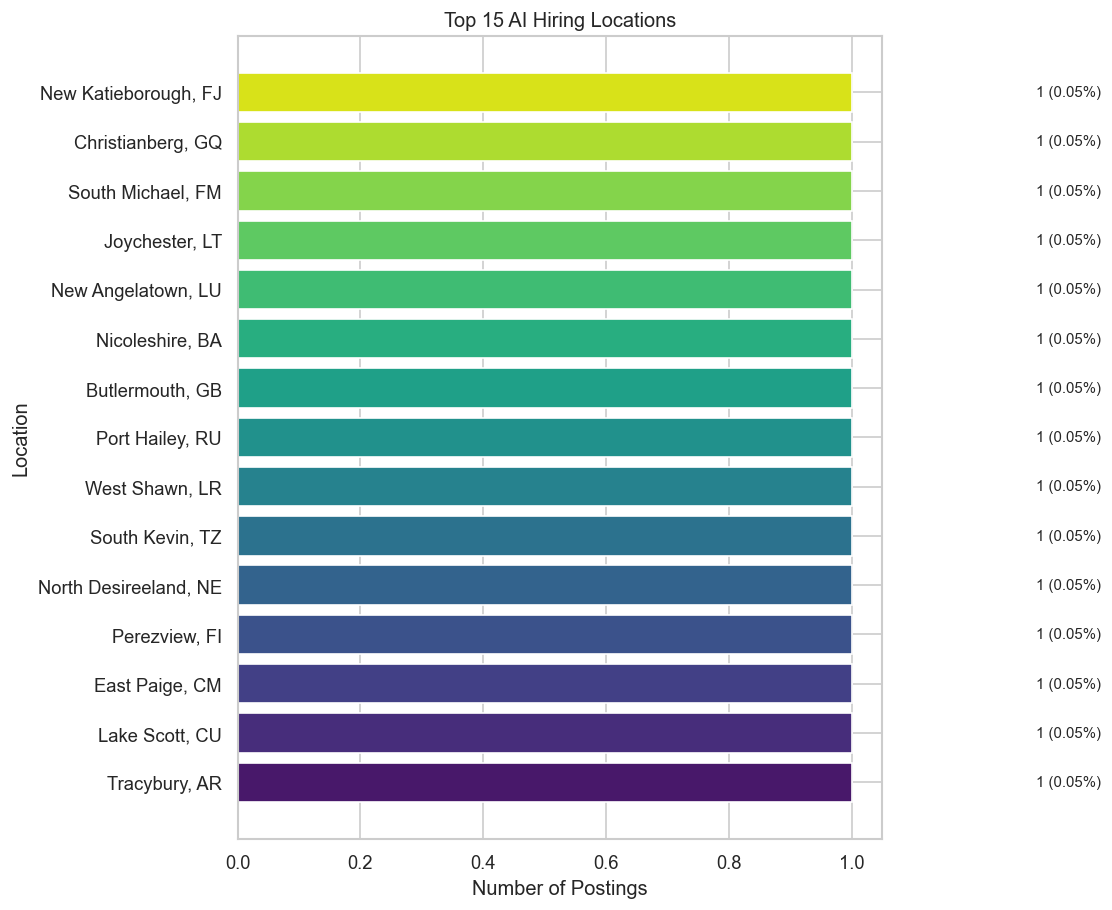

In [8]:
plot_cities = city_counts.sort_values("count")

fig, ax = plt.subplots(figsize=(10, TOP_N_CITIES * 0.45 + 1))
colors = palette(len(plot_cities))
ax.barh(plot_cities["location"], plot_cities["count"], color=colors)

for i, (cnt, pct) in enumerate(zip(plot_cities["count"], plot_cities["share_pct"])):
    ax.text(cnt + 0.3, i, f"{cnt} ({pct}%)", va="center", fontsize=9)

ax.set_title(f"Top {TOP_N_CITIES} AI Hiring Locations")
ax.set_xlabel("Number of Postings")
ax.set_ylabel("Location")
plt.tight_layout()
save_fig("top_hiring_cities.png")
plt.show()

**Insight**: The top hiring cities represent the major AI talent hubs. Cities clustered
with a high share percentage indicate **geographic concentration of demand** — moving to
or targeting these markets substantially increases opportunity volume. Cities lower on
the list may offer **less competition** for a smaller pool of roles, which can benefit
candidates with local ties or specific industry focus.

## 5. Salary by Location

Box plots compare salary distributions for the top hiring cities. This reveals whether
geographic concentration translates into salary premiums — cities with both high volume
and high median salary represent the strongest overall opportunity markets.

In [9]:
TOP_N_SAL_CITIES = 10

if "salary_avg" in df.columns:
    top_locs = df["location"].value_counts().head(TOP_N_SAL_CITIES).index.tolist()
    loc_subset = df[df["location"].isin(top_locs)][["location", "salary_avg"]].dropna()

    loc_order = (
        loc_subset.groupby("location")["salary_avg"]
        .median()
        .sort_values()
        .index.tolist()
    )

    loc_sal_stats = (
        loc_subset.groupby("location")["salary_avg"]
        .agg(count="count", median="median", mean="mean", std="std")
        .round(0)
        .reindex(loc_order[::-1])  # high to low
        .reset_index()
    )
    display(loc_sal_stats)

,location,count,median,mean,std
0,"East Paige, CM",1,"170,850.00","170,850.00",NaN
1,"Butlermouth, GB",1,"161,372.00","161,372.00",NaN
2,"South Kevin, TZ",1,"136,675.00","136,675.00",NaN
3,"Nicoleshire, BA",1,"122,195.00","122,195.00",NaN
4,"North Desireeland, NE",1,"117,054.00","117,054.00",NaN
5,"Lake Scott, CU",1,"111,699.00","111,699.00",NaN
6,"Tracybury, AR",1,"101,229.00","101,229.00",NaN
7,"Perezview, FI",1,"87,326.00","87,326.00",NaN
8,"West Shawn, LR",1,"79,584.00","79,584.00",NaN
9,"Port Hailey, RU",1,"72,588.00","72,588.00",NaN


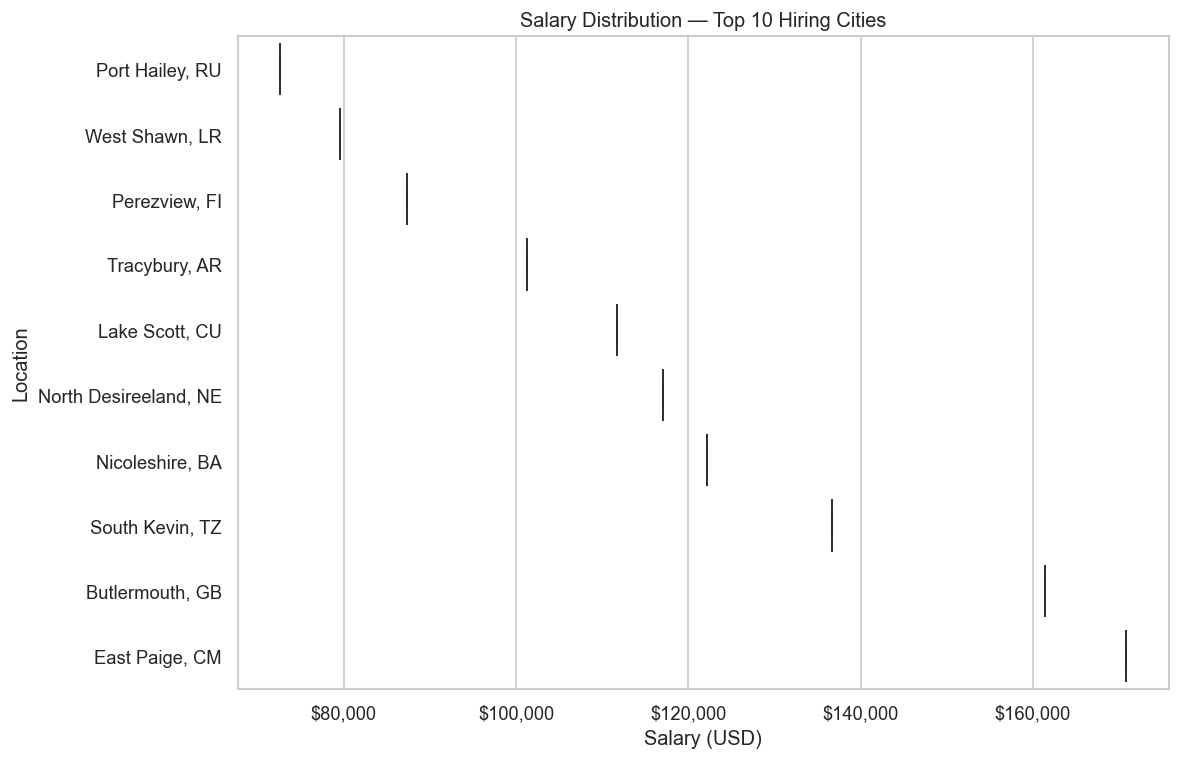

In [10]:
if "salary_avg" in df.columns:
    fig, ax = plt.subplots(figsize=(10, TOP_N_SAL_CITIES * 0.55 + 1))
    sns.boxplot(
        data=loc_subset,
        y="location",
        x="salary_avg",
        order=loc_order,
        palette=palette(len(loc_order)),
        ax=ax,
    )
    ax.set_title(f"Salary Distribution — Top {TOP_N_SAL_CITIES} Hiring Cities")
    ax.set_xlabel("Salary (USD)")
    ax.set_ylabel("Location")
    fmt_usd(ax, "x")
    plt.tight_layout()
    save_fig("salary_by_location.png")
    plt.show()

**Insight**: Cities ranked higher on this chart offer not only more postings but also
higher median compensation — confirming a **volume-premium correlation** in top AI markets.
Wide IQR boxes for certain cities indicate high variability driven by the mix of roles
and industries present. Candidates should weigh **local cost-of-living** against gross
salary when comparing geographic opportunities.

## 6. Industry Composition by City

The stacked bar chart shows which industries dominate hiring in each top city.
Cities dominated by a single industry represent concentrated bets — high opportunity
for specialists in that sector, lower flexibility for those with cross-industry profiles.

In [11]:
TOP_N_IND_CITIES = 8
top_cities = df["location"].value_counts().head(TOP_N_IND_CITIES).index.tolist()
city_ind = df[df["location"].isin(top_cities)]

pivot = (
    city_ind.groupby(["location", "industry"])
    .size()
    .unstack(fill_value=0)
    .reindex(top_cities)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.round(1)

industry,Automotive,E-commerce,Education,Finance,Healthcare,Tech
location,,,,,,
"Tracybury, AR",0.00,0.00,0.00,0.00,100.00,0.00
"Lake Scott, CU",0.00,0.00,0.00,0.00,0.00,100.00
"East Paige, CM",0.00,0.00,0.00,0.00,0.00,100.00
"Perezview, FI",0.00,0.00,0.00,0.00,0.00,100.00
"North Desireeland, NE",0.00,0.00,0.00,100.00,0.00,0.00
"South Kevin, TZ",0.00,100.00,0.00,0.00,0.00,0.00
"West Shawn, LR",100.00,0.00,0.00,0.00,0.00,0.00
"Port Hailey, RU",0.00,0.00,100.00,0.00,0.00,0.00


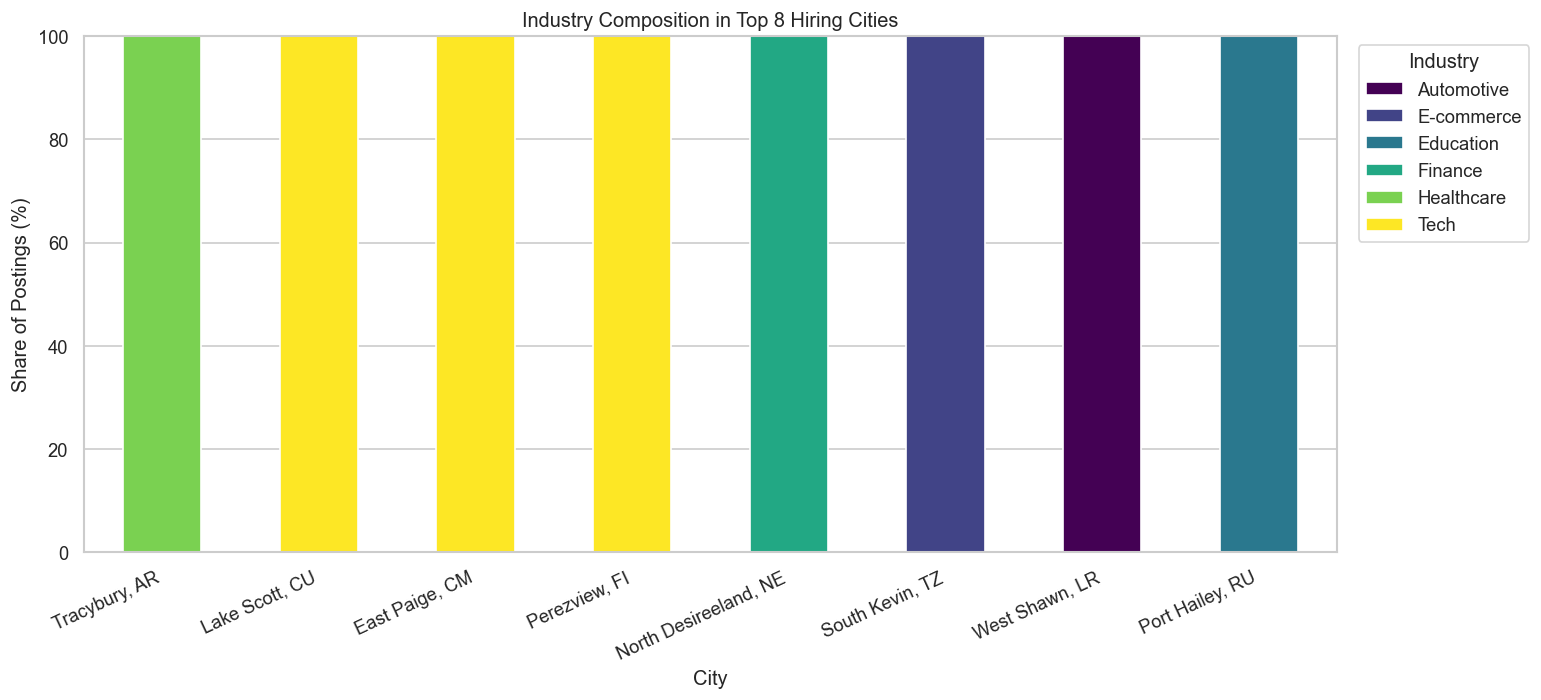

In [12]:
fig, ax = plt.subplots(figsize=(13, 6))
pivot_pct.plot(kind="bar", stacked=True, ax=ax, colormap=PALETTE)

ax.set_title(f"Industry Composition in Top {TOP_N_IND_CITIES} Hiring Cities")
ax.set_xlabel("City")
ax.set_ylabel("Share of Postings (%)")
ax.legend(title="Industry", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
save_fig("industry_composition_by_city.png")
plt.show()

**Insight**: Cities with a more **even industry distribution** offer cross-industry
flexibility — practitioners there can pivot between sectors more easily. Cities
**dominated by one industry** (e.g., a Finance hub) are ideal for specialists
but may limit optionality. Understanding this composition helps candidates align
their geographic preference with their sector target.

## 7. Industry Posting Volume & Salary

A dual-view combining posting volume (left axis) with median salary (right axis)
per industry. Industries in the top-right corner of the underlying data — high volume
AND high salary — represent the most attractive market segments.

In [13]:
ind_vol = df.groupby("industry").size().reset_index(name="job_count")

if "salary_avg" in df.columns:
    ind_sal = (
        df.dropna(subset=["salary_avg"])
        .groupby("industry")["salary_avg"]
        .agg(mean_salary="mean", median_salary="median")
        .round(0)
        .reset_index()
    )
    ind_vol = ind_vol.merge(ind_sal, on="industry", how="left")

ind_vol = ind_vol.sort_values("job_count", ascending=False).reset_index(drop=True)
ind_vol

,industry,job_count,mean_salary,median_salary
0,Automotive,300,"124,546.00","126,657.00"
1,Education,294,"121,797.00","121,193.00"
2,Retail,293,"122,791.00","123,146.00"
3,E-commerce,291,"124,745.00","128,946.00"
4,Finance,279,"123,040.00","121,813.00"
5,Tech,274,"123,217.00","120,843.00"
6,Healthcare,269,"120,964.00","122,172.00"


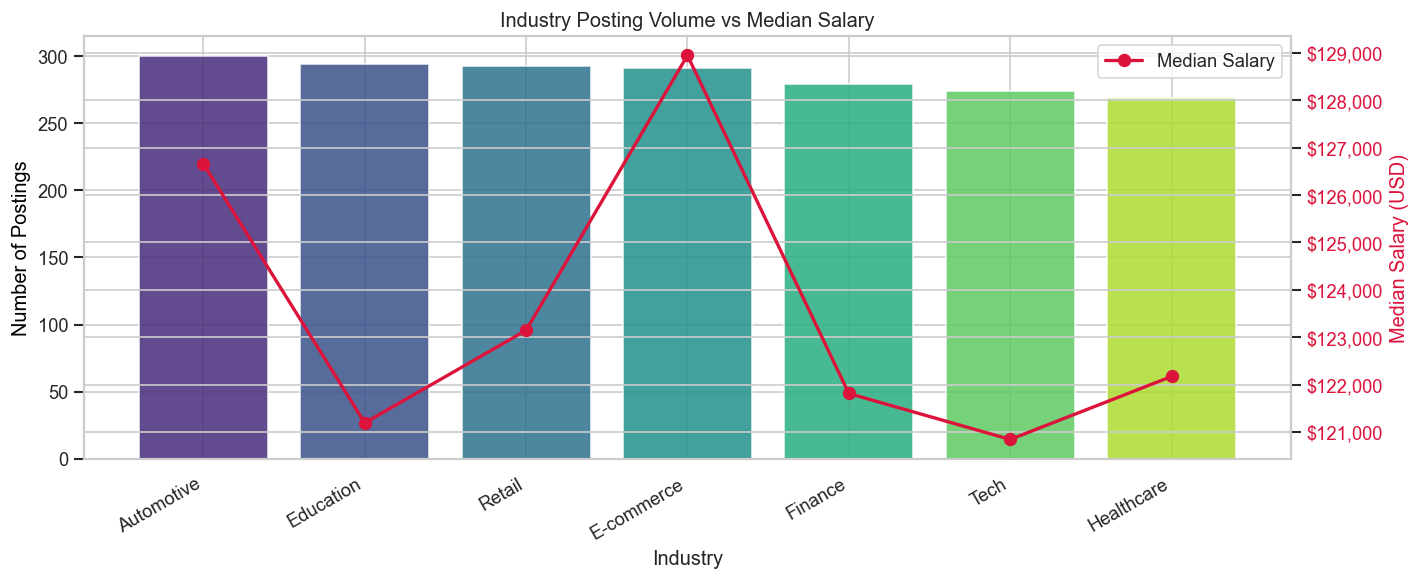

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ind_sorted = ind_vol.sort_values("job_count", ascending=False)
x = range(len(ind_sorted))

bars = ax1.bar(x, ind_sorted["job_count"], color=palette(len(ind_sorted)), alpha=0.85)
ax1.set_xlabel("Industry")
ax1.set_ylabel("Number of Postings", color="black")
ax1.set_xticks(list(x))
ax1.set_xticklabels(ind_sorted["industry"], rotation=30, ha="right")

if "median_salary" in ind_sorted.columns:
    ax2 = ax1.twinx()
    ax2.plot(
        list(x), ind_sorted["median_salary"],
        color="crimson", marker="o", linewidth=2, markersize=7, label="Median Salary"
    )
    ax2.set_ylabel("Median Salary (USD)", color="crimson")
    fmt_usd(ax2, "y")
    ax2.tick_params(axis="y", labelcolor="crimson")
    ax2.legend(loc="upper right")

ax1.set_title("Industry Posting Volume vs Median Salary")
plt.tight_layout()
save_fig("industry_volume_salary.png")
plt.show()

**Insight**: Industries where **bars are tall** (many postings) AND **the red line sits
high** (high median salary) represent the most financially and opportunity-rich segments
for AI practitioners. **Tech** and **Finance** typically show this pattern. Industries
where volume is lower but salary is high signal **niche, high-value markets** — fewer
opportunities but less competition for specialised candidates.

## 8. Role Concentration by Location

The heatmap shows how different job titles are distributed across the top cities.
Darker cells indicate higher posting volume for that role in that city — a direct
signal of where demand for specific roles is most concentrated.

In [15]:
TOP_N_ROLE_CITIES = 10
top_role_cities = df["location"].value_counts().head(TOP_N_ROLE_CITIES).index.tolist()
role_city = df[df["location"].isin(top_role_cities)]

role_pivot = (
    role_city.groupby(["location", "job_title"])
    .size()
    .unstack(fill_value=0)
    .reindex(top_role_cities)
)
role_pivot

job_title,AI Product Manager,Computer Vision Engineer,Data Analyst,Data Scientist,ML Engineer,Quant Researcher
location,,,,,,
"Tracybury, AR",0,0,1,0,0,0
"Lake Scott, CU",0,1,0,0,0,0
"East Paige, CM",0,0,0,0,0,1
"Perezview, FI",1,0,0,0,0,0
"North Desireeland, NE",0,0,0,1,0,0
"South Kevin, TZ",1,0,0,0,0,0
"West Shawn, LR",0,0,1,0,0,0
"Port Hailey, RU",0,0,0,1,0,0
"Butlermouth, GB",0,0,0,0,1,0


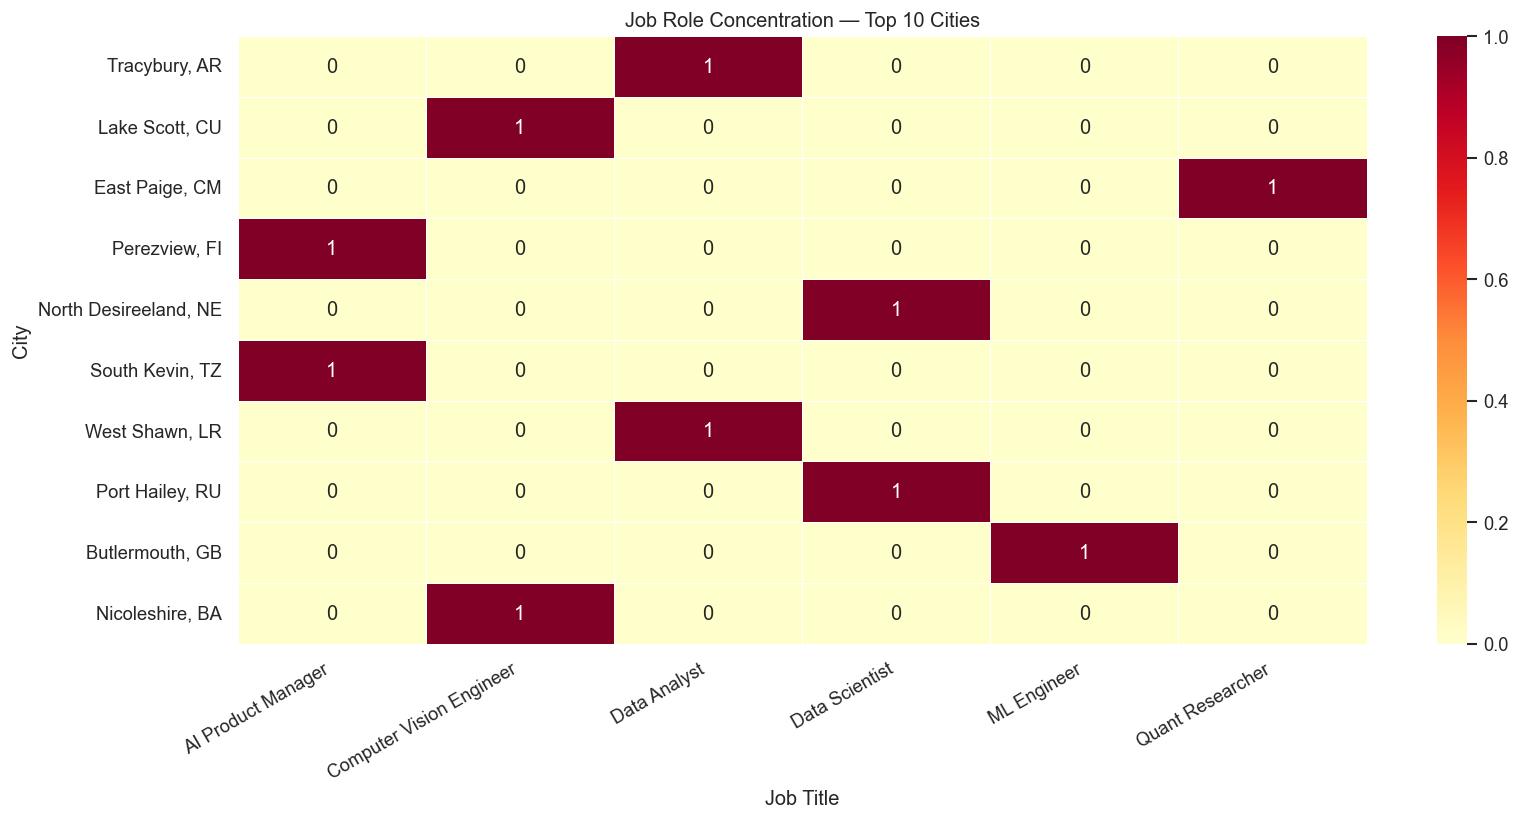

In [16]:
fig, ax = plt.subplots(figsize=(14, len(top_role_cities) * 0.6 + 1))
sns.heatmap(
    role_pivot,
    annot=True, fmt="d", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
)
ax.set_title(f"Job Role Concentration — Top {TOP_N_ROLE_CITIES} Cities")
ax.set_xlabel("Job Title")
ax.set_ylabel("City")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_fig("role_concentration_by_city.png")
plt.show()

**Insight**: Cells with the **darkest shading** reveal where specific roles are most in
demand geographically. For example, **Quant Researchers** concentrated in financial hubs
and **Computer Vision Engineers** concentrated in tech/automotive centres. Practitioners
can use this map to identify cities where their specific role has the highest density
of opportunities — maximising the number of relevant postings per search.

## 9. Key Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | A small number of cities capture a disproportionate share of AI postings | Geographic targeting to top hubs maximises opportunity volume |
| 2 | Top cities also command higher median salaries | Volume and compensation premiums align in the strongest markets |
| 3 | City industry composition varies significantly | Specialists should match target city to their sector expertise |
| 4 | Tech and Finance industries lead both posting volume and median salary | These sectors offer the strongest overall opportunity profile |
| 5 | Specific job roles are geographically concentrated | Role-specific geographic targeting reduces irrelevant search noise |

---
*Analysis based on AI job market dataset (Sep 2023 – Sep 2025).*